<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/Example_Free_and_Forced_Eccentricity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Free and Forced Eccentricity

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

In [1]:
!pip install rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.6/908.6 kB 18.1 MB/s eta 0:00:00


In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import os
from scipy.interpolate import CloughTocher2DInterpolator

## Eccentricity as a vector
---

In [3]:
# Use astronomical units, solar masses, and years.
# With this choice, G = 4*pi^2.
G = 4 * np.pi**2

plt.rcParams.update({
    "font.size": 13,
    "mathtext.fontset": "cm",
    "figure.dpi": 120
})

def eccentricity_vector(e, delta_varpi):
    """Return the eccentricity-vector components k and h."""
    k = e * np.cos(delta_varpi)
    h = e * np.sin(delta_varpi)
    return k, h

def eccentricity_from_vector(k, h):
    """Return eccentricity and angle from eccentricity-vector components."""
    e = np.sqrt(k**2 + h**2)
    delta_varpi = np.arctan2(h, k)
    return e, delta_varpi

# The Heppenheimer S-Type model
---

Here $g_H$ is the secular precession frequency and $\epsilon_H$ is the forced eccentricity.

In [4]:
def mean_motion(a, mass, G=G):
    """Return mean motion in radians per year for a semimajor axis in AU and mass in solar masses."""
    return np.sqrt(G * mass / a**3)

def heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G):
    """Return the Heppenheimer secular frequency and forced eccentricity for an S-Type planet."""
    alpha = a_p / a_bin
    mu = m_companion / (m_host + m_planet)
    n_p = mean_motion(a_p, m_host + m_planet, G=G)
    g_H = 0.75 * mu * alpha**3 * n_p / (1 - e_bin**2)**1.5
    eps_H = 1.25 * alpha * e_bin / (1 - e_bin**2)
    return g_H, eps_H

def marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G):
    """Return a Marchal-style corrected secular frequency and forced eccentricity.

    This correction follows the compact form used in the binary-stability chapter:
    g_M = g_H(1 + delta_M), eps_M = eps_H/(1 + delta_M).
    """
    g_H, eps_H = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G)
    alpha = a_p / a_bin
    mu = m_companion / (m_host + m_planet)
    delta_M = (25/8) * mu * alpha**1.5 * (3 + 2*e_bin**2) / (np.sqrt(1 + mu) * (1 - e_bin**2)**1.5)
    g_M = g_H * (1 + delta_M)
    eps_M = eps_H / (1 + delta_M)
    return g_M, eps_M, delta_M

def secular_solution(t, g, e_forced, e0, delta_varpi0=0.0):
    """Return k, h, e, and delta_varpi for the secular eccentricity-vector solution."""
    k0, h0 = eccentricity_vector(e0, delta_varpi0)
    e_free = np.sqrt((k0 - e_forced)**2 + h0**2)
    phase = np.arctan2(h0, k0 - e_forced)

    k = e_free * np.cos(g * t + phase) + e_forced
    h = e_free * np.sin(g * t + phase)
    e, delta_varpi = eccentricity_from_vector(k, h)
    return k, h, e, delta_varpi, e_free, phase

## Toy S-Type system

In [6]:
m_host = 1.0
m_planet = 0.0
m_companion = 1.0
a_p = 0.1
a_bin = 1.0
e_bin = 0.3

g_H, eps_H = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
period_sec = 2 * np.pi / g_H

print(f"The Heppenheimer forced eccentricity is eps_H = {eps_H:.4f}.")
print(f"The secular frequency is g_H = {g_H:.4f} rad/yr.")
print(f"The secular period is 2*pi/g_H = {period_sec:.2f} yr.")

The Heppenheimer forced eccentricity is eps_H = 0.0412.
The secular frequency is g_H = 0.1717 rad/yr.
The secular period is 2*pi/g_H = 36.60 yr.


## Evolve several different initial eccentricities.

The example below reproduces the basic behavior of the Heppenheimer solution. The forced eccentricity does not depend on the planet’s initial eccentricity. The initial eccentricity only changes the size of the free oscillation around the forced point.

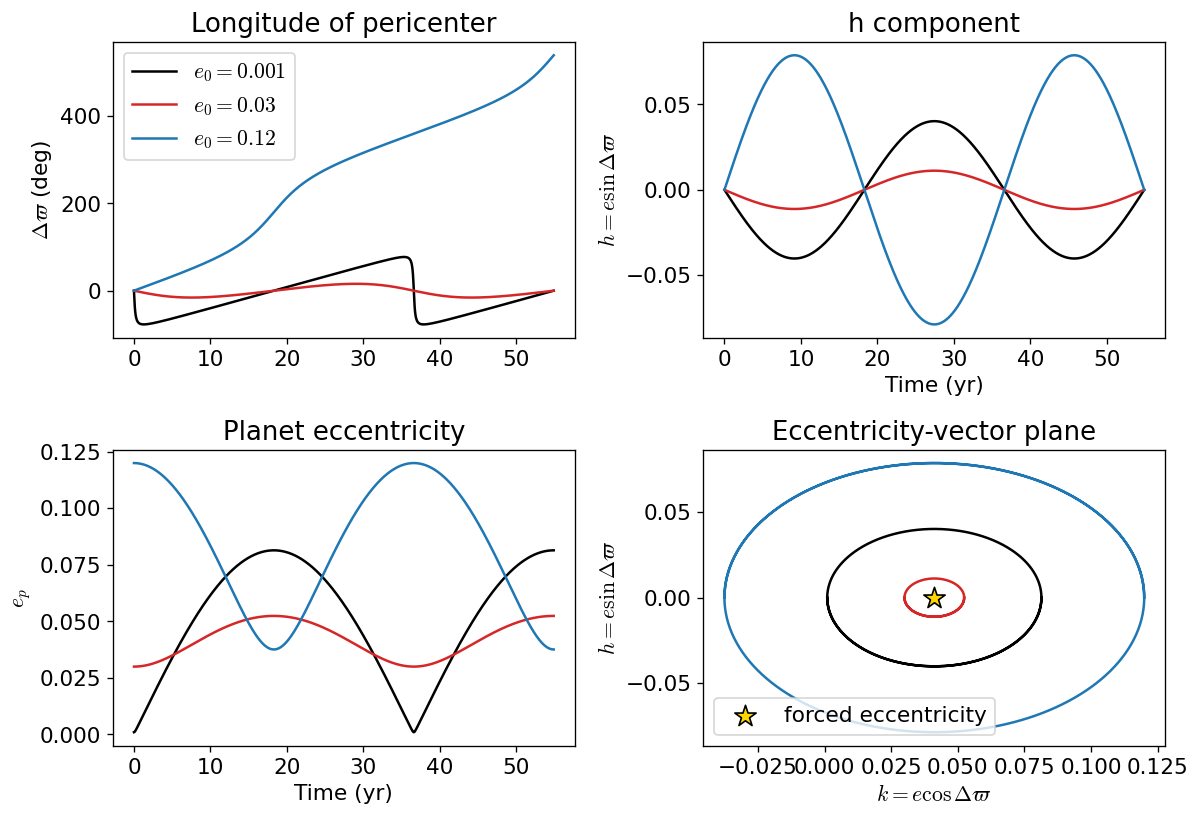

In [7]:
t = np.linspace(0, 1.5 * period_sec, 1000)
initial_eccentricities = [0.001, 0.03, 0.12]
colors = ["black", "tab:red", "tab:blue"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)

for e0, color in zip(initial_eccentricities, colors):
    k, h, e, dvarpi, e_free, phase = secular_solution(t, g_H, eps_H, e0, delta_varpi0=0.0)
    axes[0, 0].plot(t, np.degrees(np.unwrap(dvarpi)), color=color, label=rf"$e_0={e0}$")
    axes[1, 0].plot(t, e, color=color)
    axes[0, 1].plot(t, h, color=color)
    axes[1, 1].plot(k, h, color=color)

axes[1, 1].scatter([eps_H], [0], marker="*", s=180, color="gold", edgecolor="black", zorder=5, label="forced eccentricity")
axes[0, 0].set_ylabel(r"$\Delta\varpi$ (deg)")
axes[1, 0].set_ylabel(r"$e_p$")
axes[0, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 0].set_xlabel("Time (yr)")
axes[0, 1].set_xlabel("Time (yr)")
axes[1, 1].set_xlabel(r"$k=e\cos\Delta\varpi$")
axes[0, 0].legend(loc="best")
axes[1, 1].legend(loc="best")
axes[0, 0].set_title("Longitude of pericenter")
axes[1, 0].set_title("Planet eccentricity")
axes[0, 1].set_title("h component")
axes[1, 1].set_title("Eccentricity-vector plane")

plt.tight_layout()
plt.show()

## Free eccentricity and maximum eccentricity

---

In [8]:
def free_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=0.0):
    """Return free eccentricity relative to a forced eccentricity vector."""
    k0 = e0 * np.cos(delta_varpi0)
    h0 = e0 * np.sin(delta_varpi0)
    kF = e_forced * np.cos(varpi_forced)
    hF = e_forced * np.sin(varpi_forced)
    return np.sqrt((k0 - kF)**2 + (h0 - hF)**2)

def max_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=0.0):
    """Return approximate secular maximum eccentricity."""
    e_free = free_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=varpi_forced)
    return e_forced + e_free

## Show how initial eccentricity and pericenter alignment change e_max.

The dark minimum in the map occurs near $e_0 = \epsilon_H$ and $\Delta \bar{\omega} = 0$. That is the initial condition closest to the forced eccentricity vector. For an S-Type planet, the forced vector usually points in the direction of the binary pericenter in this simple model. Starting aligned with the binary and near the forced eccentricity minimizes the free eccentricity.

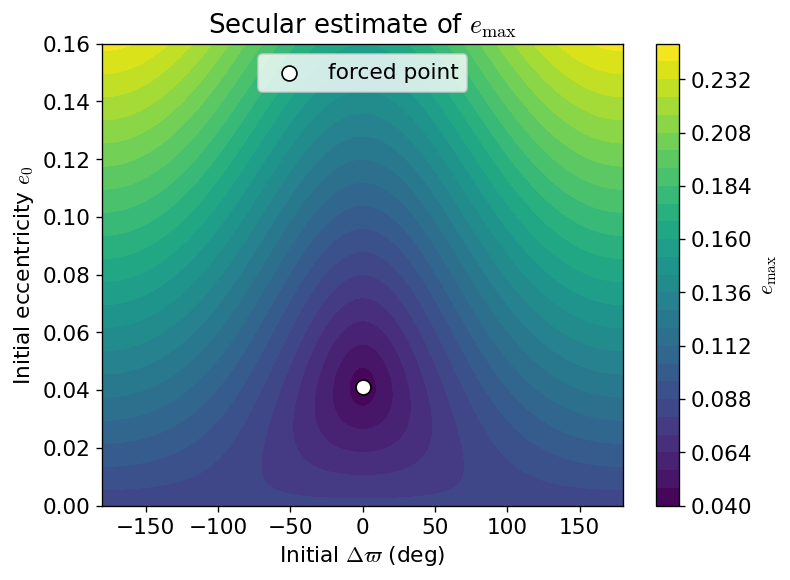

In [9]:
e0_grid = np.linspace(0, 0.16, 150)
dvarpi_grid = np.radians(np.linspace(-180, 180, 241))
DVARPI, E0 = np.meshgrid(dvarpi_grid, e0_grid)
EMAX = max_eccentricity(E0, DVARPI, eps_H)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(np.degrees(DVARPI), E0, EMAX, levels=25)
ax.scatter([0], [eps_H], color="white", edgecolor="black", s=80, zorder=4, label="forced point")
ax.set_xlabel(r"Initial $\Delta\varpi$ (deg)")
ax.set_ylabel(r"Initial eccentricity $e_0$")
ax.set_title(r"Secular estimate of $e_{\max}$")
fig.colorbar(cs, ax=ax, label=r"$e_{\max}$")
ax.legend(loc="upper center")
plt.show()

## First-order, Marchal, and empirical corrections
---

This correction shifts the secular frequency and forced eccentricity while keeping the same geometric picture: the eccentricity vector still circulates around a forced point.

In [10]:
g_M, eps_M, delta_M = marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)

print(f"For this toy system, delta_M = {delta_M:.4f}.")
print(f"Heppenheimer: g_H = {g_H:.4f} rad/yr, eps_H = {eps_H:.4f}.")
print(f"Marchal-style corrected: g_M = {g_M:.4f} rad/yr, eps_M = {eps_M:.4f}.")
print(f"The corrected secular period is {2*np.pi/g_M:.2f} yr.")

For this toy system, delta_M = 0.2560.
Heppenheimer: g_H = 0.1717 rad/yr, eps_H = 0.0412.
Marchal-style corrected: g_M = 0.2156 rad/yr, eps_M = 0.0328.
The corrected secular period is 29.14 yr.


## Andrade-Ines style empirical correction


The binary-stability chapter describes a more flexible empirical correction that can be represented as finite sums. This is the same idea as the compact correction above, but with coefficients fitted to a broader set of numerical experiments.

In [11]:
def finite_sum_correction(alpha, mu, e_bin, coeffs):
    """Evaluate a finite-sum correction.

    Parameters
    ----------
    alpha : float
        Semimajor axis ratio.
    mu : float
        Perturber mass ratio.
    e_bin : float
        Binary eccentricity.
    coeffs : list of tuples
        Each tuple should contain (A, p, q, ell).

    Returns
    -------
    correction : float
        The value of sum A * alpha**p * mu**q * e_bin**ell.
    """
    correction = 0.0
    for A, p, q, ell in coeffs:
        correction += A * alpha**p * mu**q * e_bin**ell
    return correction

# Example only: replace this with a published coefficient table before using in research.
example_coeffs = [
    (0.0, 0, 0, 0),
]

alpha = a_p / a_bin
mu = m_companion / (m_host + m_planet)
delta_example = finite_sum_correction(alpha, mu, e_bin, example_coeffs)

print(f"Example finite-sum correction = {delta_example:.3f}.")
print("Replace example_coeffs with the published coefficient table before using this correction.")

Example finite-sum correction = 0.000.
Replace example_coeffs with the published coefficient table before using this correction.


## Applicability domains
---

Andrade-Ines et al. emphasized that the first-order model is algebraically simple and easy to implement, but it only works where the perturbation is sufficiently small. A second-order model increases the range of validity, but even that model fails when short-period terms, mean motion resonances, or instability dominate the evolution. The exact numerical boundary depends on the binary mass ratio, binary eccentricity, planetary semimajor axis, and initial conditions. The qualitative ordering is more important for a first pass:

$\text{simple secular model} → \text{corrected secular model} → \text{short period/MMR effects} → \text{instability.}$

In [12]:
def summarize_s_type_regime(alpha, e_planet=None):
    """Return a rough qualitative warning for S-Type secular modeling.

    This is not a stability criterion. It is only a teaching-level guide to
    when the first-order model should be treated with increasing caution.
    """
    if alpha < 0.05:
        return "deeply hierarchical: first-order secular model is usually a good benchmark"
    if alpha < 0.10:
        return "hierarchical: first-order model is useful, but corrections should be checked"
    if alpha < 0.20:
        return "moderately perturbed: use corrected secular theory and compare with N-body"
    return "strongly perturbed: secular theory may fail; check MMRs and stability with N-body"

for test_alpha in [0.03, 0.08, 0.15, 0.25]:
    print(f"alpha = {test_alpha:.2f}: {summarize_s_type_regime(test_alpha)}")

alpha = 0.03: deeply hierarchical: first-order secular model is usually a good benchmark
alpha = 0.08: hierarchical: first-order model is useful, but corrections should be checked
alpha = 0.15: moderately perturbed: use corrected secular theory and compare with N-body
alpha = 0.25: strongly perturbed: secular theory may fail; check MMRs and stability with N-body


## P-Type architecture
---

The forced/free eccentricity picture still applies to P-Type planets. The eccentricity vector still oscillates around a forced value, but the forcing comes from the inner binary rather than from an external stellar companion.

## Circumbinary secular model
---

In [13]:
def moriwaki_nakagawa_p_type(m_A, m_B, a_bin, a_p, e_bin, G=G):
    """Return the Moriwaki-Nakagawa secular frequency and forced eccentricity for a P-Type planet."""
    mu_dag = m_B / (m_A + m_B)
    alpha = a_p / a_bin
    n_bin = mean_motion(a_bin, m_A + m_B, G=G)
    n_p = mean_motion(a_p, m_A + m_B, G=G)
    g_MN = 0.75 * mu_dag * (1 - mu_dag) * alpha**(-5) * (n_bin**2 / n_p) * (1 + 1.5 * e_bin**2)
    eps_MN = 1.25 * (1 - 2 * mu_dag) * alpha**(-1) * e_bin * (1 + 0.75 * e_bin**2) / (1 + 1.5 * e_bin**2)
    return g_MN, eps_MN

# Toy P-Type system.
m_A = 1.0
m_B = 0.3
a_bin = 1.0
a_p = 5.0
e_bin = 0.3

g_MN, eps_MN = moriwaki_nakagawa_p_type(m_A, m_B, a_bin, a_p, e_bin)
period_MN = 2 * np.pi / g_MN

print(f"The P-Type forced eccentricity is eps_MN = {eps_MN:.4f}.")
print(f"The P-Type secular period is 2*pi/g_MN = {period_MN:.2f} yr.")

The P-Type forced eccentricity is eps_MN = 0.0380.
The P-Type secular period is 2*pi/g_MN = 1622.30 yr.


## Evolve a P-Type example with three initial eccentricities

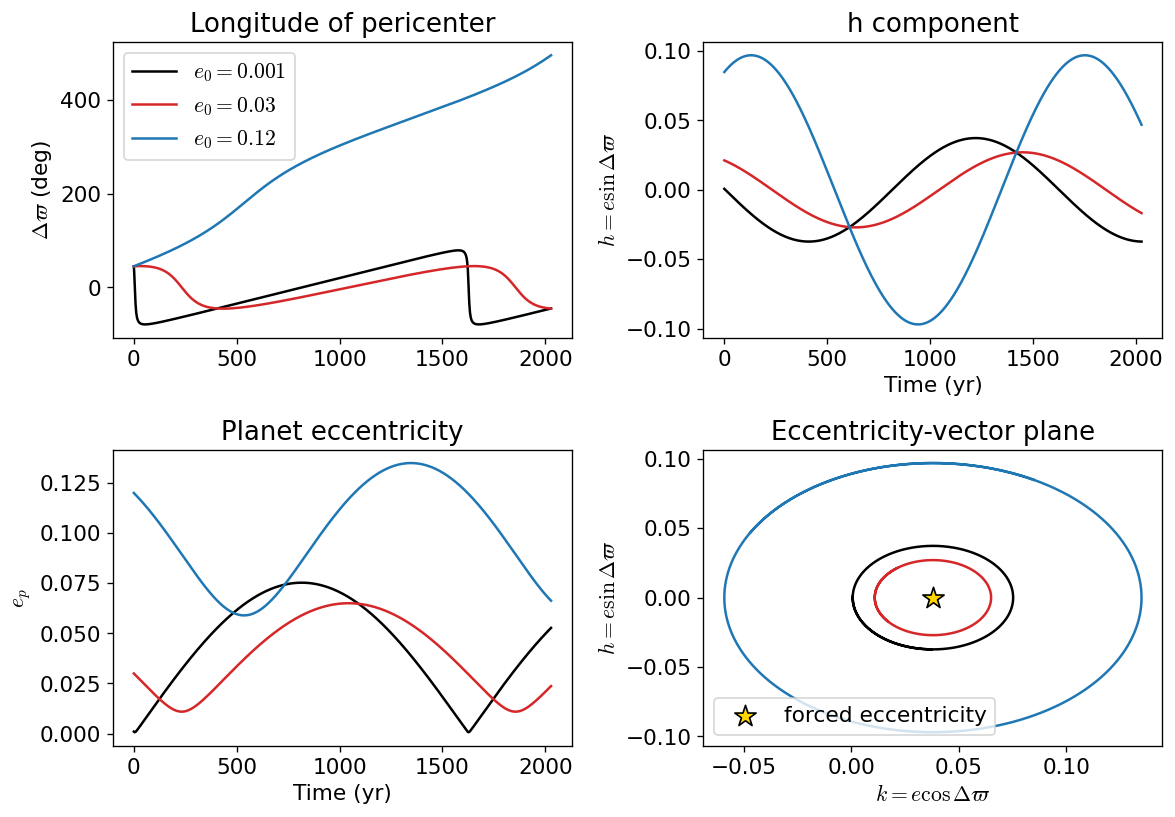

In [14]:
t = np.linspace(0, 1.25 * period_MN, 1200)
initial_eccentricities = [0.001, 0.03, 0.12]
delta_varpi0 = np.radians(45)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)

for e0, color in zip(initial_eccentricities, colors):
    k, h, e, dvarpi, e_free, phase = secular_solution(t, g_MN, eps_MN, e0, delta_varpi0=delta_varpi0)
    axes[0, 0].plot(t, np.degrees(np.unwrap(dvarpi)), color=color, label=rf"$e_0={e0}$")
    axes[1, 0].plot(t, e, color=color)
    axes[0, 1].plot(t, h, color=color)
    axes[1, 1].plot(k, h, color=color)

axes[1, 1].scatter([eps_MN], [0], marker="*", s=180, color="gold", edgecolor="black", zorder=5, label="forced eccentricity")
axes[0, 0].set_ylabel(r"$\Delta\varpi$ (deg)")
axes[1, 0].set_ylabel(r"$e_p$")
axes[0, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 0].set_xlabel("Time (yr)")
axes[0, 1].set_xlabel("Time (yr)")
axes[1, 1].set_xlabel(r"$k=e\cos\Delta\varpi$")
axes[0, 0].legend(loc="best")
axes[1, 1].legend(loc="best")
axes[0, 0].set_title("Longitude of pericenter")
axes[1, 0].set_title("Planet eccentricity")
axes[0, 1].set_title("h component")
axes[1, 1].set_title("Eccentricity-vector plane")

plt.tight_layout()
plt.show()

## Fast and slow circumbinary eccentricity components
---

The low-order secular forced eccentricity for a P-Type planet can become very small for symmetric binaries. However, circumbinary orbits also have short-period variations caused by the binary’s fast orbital motion.

In [15]:
def fast_forced_circumbinary(m_A, m_B, a_bin, a_p, e_bin):
    """Return the fast circumbinary eccentricity estimate."""
    mu_dag = m_B / (m_A + m_B)
    alpha = a_p / a_bin
    eps_ff = 0.75 * mu_dag * (1 - mu_dag) * alpha**(-2) * np.sqrt(1 + (34/3) * e_bin**2)
    return eps_ff

eps_ff = fast_forced_circumbinary(m_A, m_B, a_bin, a_p, e_bin)
e_mean_est = 4/np.pi * (abs(eps_MN) + eps_ff)

print(f"The slow secular forced eccentricity magnitude is |eps_MN| = {abs(eps_MN):.4f}.")
print(f"The fast eccentricity estimate is eps_ff = {eps_ff:.4f}.")
print(f"The rough mean eccentricity estimate is <e_p> = {e_mean_est:.4f}.")

The slow secular forced eccentricity magnitude is |eps_MN| = 0.0380.
The fast eccentricity estimate is eps_ff = 0.0076.
The rough mean eccentricity estimate is <e_p> = 0.0580.


## Benchmarking against an N-body simulation
---

The secular model is useful because it is cheap and transparent. An N-body model is more complete because it retains short-period terms, resonant effects, and non-linear behavior. A good workflow is:


1.   use the secular model to predict $e_\text{forced}$ and $g$,
2.   choose initial conditions with a known $e_\text{free}$,
3.   run the N-body simulation,
4.   compare the measured eccentricity oscillation against the secular prediction,
5.   investigate any disagreement.

If the N-body result disagrees with the secular model, first check the assumptions: Is $\alpha$ small enough? Is the planet near a mean motion resonance? Is the eccentricity too large? Is the system near the stability boundary?



In [16]:
def run_optional_rebound_s_type_example():
    """Run a short S-Type REBOUND simulation if REBOUND is installed.

    This example uses the same S-Type toy model as the Heppenheimer secular example:
    a planet orbits the host star m1, while the stellar companion m3 is the external perturber.

    This is a demonstration cell, not a production-quality stability simulation.
    """

    # ------------------------------------------------------------
    # S-Type toy model parameters
    # ------------------------------------------------------------
    m1 = 1.0          # host star mass in solar masses
    m2 = 0.0          # planet treated as a test particle
    m3 = 1.0          # stellar companion mass in solar masses

    a_bin = 1.0       # binary semimajor axis in AU
    e_bin = 0.3       # binary eccentricity

    alpha = 0.1       # S-Type hierarchy parameter: alpha = a_p / a_bin
    a_p = alpha * a_bin

    # The S-Type secular model uses the perturber mass ratio m3/(m1 + m2).
    mu_sec = m3 / (m1 + m2)

    # Planet mean motion around the host star.
    n_p = np.sqrt(4 * np.pi**2 * (m1 + m2) / a_p**3)

    # Heppenheimer forced eccentricity and secular frequency.
    e_forced = 1.25 * alpha * e_bin / (1 - e_bin**2)
    g_sec = 0.75 * mu_sec * alpha**3 * n_p / (1 - e_bin**2)**1.5
    period_sec = 2 * np.pi / g_sec

    # Keplerian periods used only to choose a reasonable timestep.
    period_p = np.sqrt(a_p**3 / (m1 + m2))
    period_bin = np.sqrt(a_bin**3 / (m1 + m3))
    dt = min(period_p / 40, period_bin / 100)

    # ------------------------------------------------------------
    # Build the REBOUND simulation
    # ------------------------------------------------------------
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.integrator = "whfast"
    sim.dt = dt

    # Add the host star.
    sim.add(m=m1)

    # Add the S-Type planet around the host star.
    # Starting the planet near the forced eccentricity reduces the free eccentricity.
    sim.add(m=m2, a=a_p, e=e_forced, omega=0.0, f=0.0, primary=sim.particles[0])

    # Add the stellar companion as the outer perturber.
    # Because the planet is massless, using the host star as the primary is equivalent
    # to using the center of mass of the inner pair for this toy setup.
    sim.add(m=m3, a=a_bin, e=e_bin, omega=0.0, f=0.0, primary=sim.particles[0])

    sim.move_to_com()

    # ------------------------------------------------------------
    # Integrate and record osculating eccentricity
    # ------------------------------------------------------------
    times = np.linspace(0, 2 * period_sec, 500)
    ecc = np.zeros_like(times)

    for i, time in enumerate(times):
        sim.integrate(time)
        orbit = sim.particles[1].orbit(primary=sim.particles[0])
        ecc[i] = orbit.e

    return times, ecc, e_forced, period_sec

The S-Type forced eccentricity used for the initial planet orbit is e_F = 0.0412.
The secular period from the toy model is 36.6 yr.


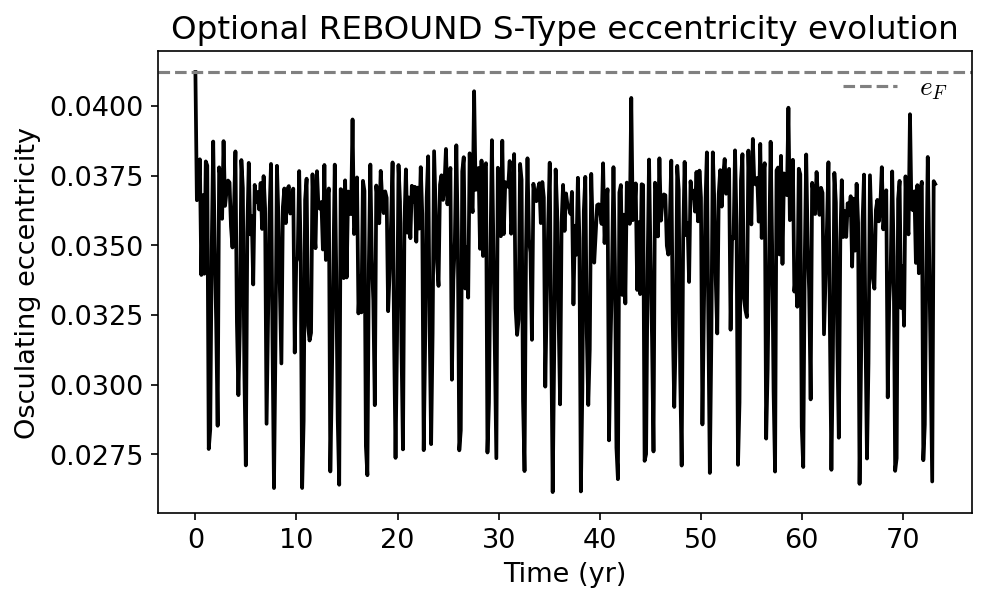

In [17]:
result = run_optional_rebound_s_type_example()

if result is not None:
    times, ecc, e_forced, period_sec = result

    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(times, ecc, color="black", linewidth=1.8)
    ax.axhline(e_forced, color="0.5", linestyle="--", linewidth=1.5, label=r"$e_F$")

    ax.set_xlabel("Time (yr)")
    ax.set_ylabel("Osculating eccentricity")
    ax.set_title("Optional REBOUND S-Type eccentricity evolution")
    ax.legend(frameon=False)

    print(f"The S-Type forced eccentricity used for the initial planet orbit is e_F = {e_forced:.4f}.")
    print(f"The secular period from the toy model is {period_sec:.1f} yr.")

    plt.show()

## Copy-paste reference
---

This section collects the main reusable functions from the guide.



In [18]:
def s_type_forced_free_summary(m_host, m_planet, m_companion, a_p, a_bin, e_bin, e0, delta_varpi0, model="heppenheimer"):
    """Return a dictionary summarizing an S-Type secular model."""
    if model == "heppenheimer":
        g, e_forced = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
    elif model == "marchal":
        g, e_forced, _ = marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
    else:
        raise ValueError("model must be 'heppenheimer' or 'marchal'")

    e_free = free_eccentricity(e0, delta_varpi0, e_forced)
    return {
        "g": g,
        "secular_period": 2 * np.pi / g,
        "e_forced": e_forced,
        "e_free": e_free,
        "e_min": abs(e_forced - e_free),
        "e_max": e_forced + e_free,
    }

summary = s_type_forced_free_summary(m_host, m_planet, m_companion, a_p, a_bin, e_bin, e0=0.0, delta_varpi0=0.0)

for key, value in summary.items():
    print(f"{key}: {value:.5f}")

g: 60.69236
secular_period: 0.10353
e_forced: 2.06044
e_free: 2.06044
e_min: 0.00000
e_max: 4.12088


## References and source notes
---

This guide is based on the standard secular eccentricity-vector picture used in studies of planets in binary-star systems. The most important source ideas are:



*   Heppenheimer’s first-order S-Type secular model.
*   Marchal-style corrected S-Type secular frequencies and forced eccentricities.
*   Andrade-Ines et al.’s discussion of applicability domains for first- and second-order secular theories.
*   Moriwaki and Nakagawa’s circumbinary forced-eccentricity model.
*   Numerical comparisons showing where secular models match or fail against N-body integrations.

